# Orange County Residential: Price Trend Forecasting

**Goal:** Forecast 12-month price trends for key Orange County cities using Zillow Home Value Index time series data.

**Methods:**
1. Time series decomposition (trend + seasonality)
2. SARIMA model for city-level forecasts
3. Redfin transaction-level market health indicators

**Output:** 12-month price forecasts with confidence intervals for Orange County's top submarkets.

---

> *Note: ZHVI is a repeat-sales index for all homes — multifamily-specific price data at zip level is not
> publicly available. ZHVI directionally tracks MF/SFR rental values and is the standard proxy used in
> market analysis. Orange County is a single county with 30+ cities, so forecasts are broken out by
> **city** rather than county (unlike the nine-county Bay Area version of this analysis).*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

DATA = Path('../data/raw')
OUT  = Path('../outputs')
(OUT / 'charts').mkdir(exist_ok=True)
(OUT / 'tables').mkdir(exist_ok=True)

## 1. Build time series dataset

In [2]:
zhvi = pd.read_csv(DATA / 'zillow_zhvi_zip.csv', dtype={'RegionName': str})

meta_cols = ['RegionID','SizeRank','RegionName','RegionType','StateName','State','City','Metro','CountyName']
date_cols = sorted([c for c in zhvi.columns if c not in meta_cols])

# Use data from 2015 onward — enough history for SARIMA, avoids pre-GFC noise
date_cols_recent = [c for c in date_cols if c >= '2015-01-01']

print(f'ZHVI: {len(zhvi)} Orange County zip codes')
print(f'Time series: {date_cols_recent[0]} \u2192 {date_cols_recent[-1]} ({len(date_cols_recent)} months)')
print(f'\nZip count by city (top 10):')
print(zhvi['City'].value_counts().head(10))

ZHVI: 86 Orange County zip codes
Time series: 2015-01-31 → 2026-05-31 (137 months)

Zip count by city (top 10):
City
Irvine              9
Anaheim             7
Newport Beach       6
Santa Ana           5
Orange              5
Huntington Beach    5
Garden Grove        5
Fullerton           4
Dana Point          2
Brea                2
Name: count, dtype: int64


In [3]:
# Melt to long format for analysis
zhvi_long = zhvi[meta_cols + date_cols_recent].melt(
    id_vars=meta_cols,
    var_name='date',
    value_name='zhvi'
)
zhvi_long['date'] = pd.to_datetime(zhvi_long['date'])

# City-level aggregate (mean of zip ZHVIs) — Orange County is one county with 30+ cities,
# so city is the meaningful submarket unit here (unlike the multi-county Bay Area version)
city_ts = zhvi_long.groupby(['date','City'])['zhvi'].mean().reset_index()
city_ts = city_ts.sort_values(['City','date'])

print(f'Long format: {len(zhvi_long):,} rows')

Long format: 11,782 rows


## 2. Orange County price history overview

Key cities for forecasting: ['Irvine', 'Anaheim', 'Newport Beach', 'Santa Ana', 'Orange']


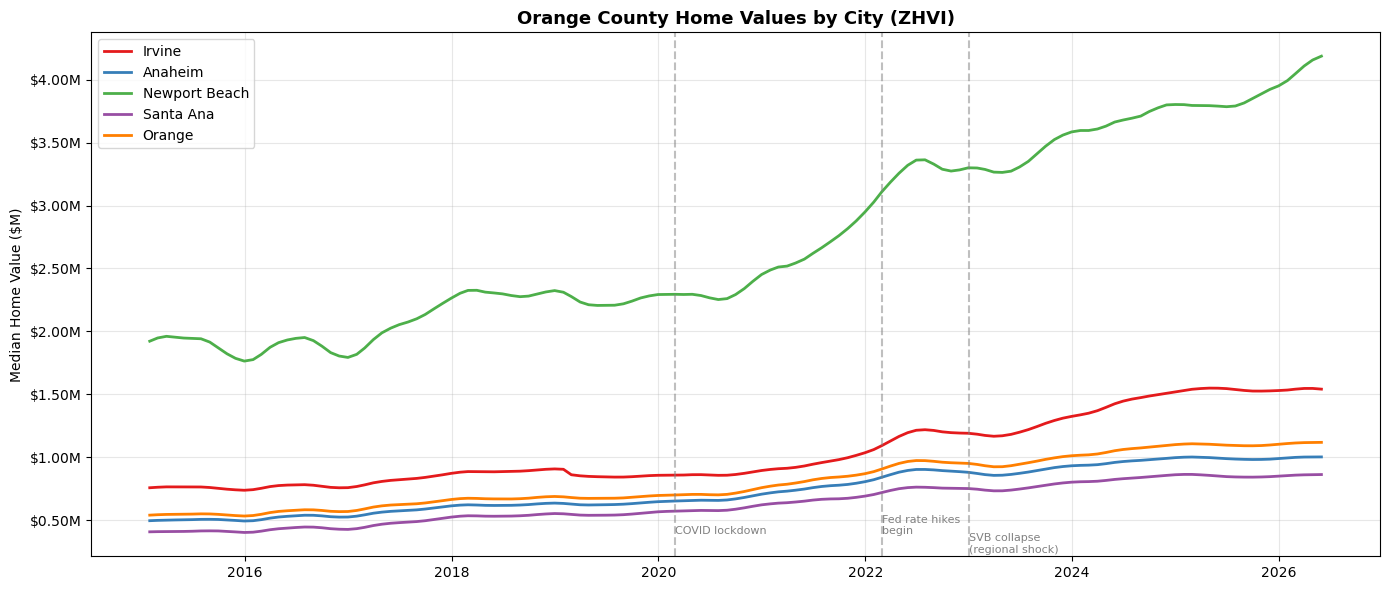

In [4]:
# Top 5 cities by zip-code count (broad coverage across price points)
key_cities = zhvi['City'].value_counts().head(5).index.tolist()
print('Key cities for forecasting:', key_cities)

fig, ax = plt.subplots(figsize=(14, 6))

colors = ['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00']
for city, color in zip(key_cities, colors):
    ts = city_ts[city_ts['City'] == city]
    if ts.empty:
        continue
    ax.plot(ts['date'], ts['zhvi'] / 1e6, label=city, color=color, linewidth=2)

events = {
    '2020-03': ('COVID lockdown', 0.3),
    '2022-03': ('Fed rate hikes\nbegin', 0.3),
    '2023-01': ('SVB collapse\n(regional shock)', 0.15),
}
for date_str, (label, ypos) in events.items():
    ax.axvline(pd.Timestamp(date_str), color='gray', linestyle='--', alpha=0.5)
    ax.text(pd.Timestamp(date_str), ax.get_ylim()[1]*0.02 + ypos, label, fontsize=8, rotation=0, color='gray')

ax.set_ylabel('Median Home Value ($M)')
ax.set_title('Orange County Home Values by City (ZHVI)', fontweight='bold', fontsize=13)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.2f}M'))
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT / 'charts/city_price_history.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Time series decomposition

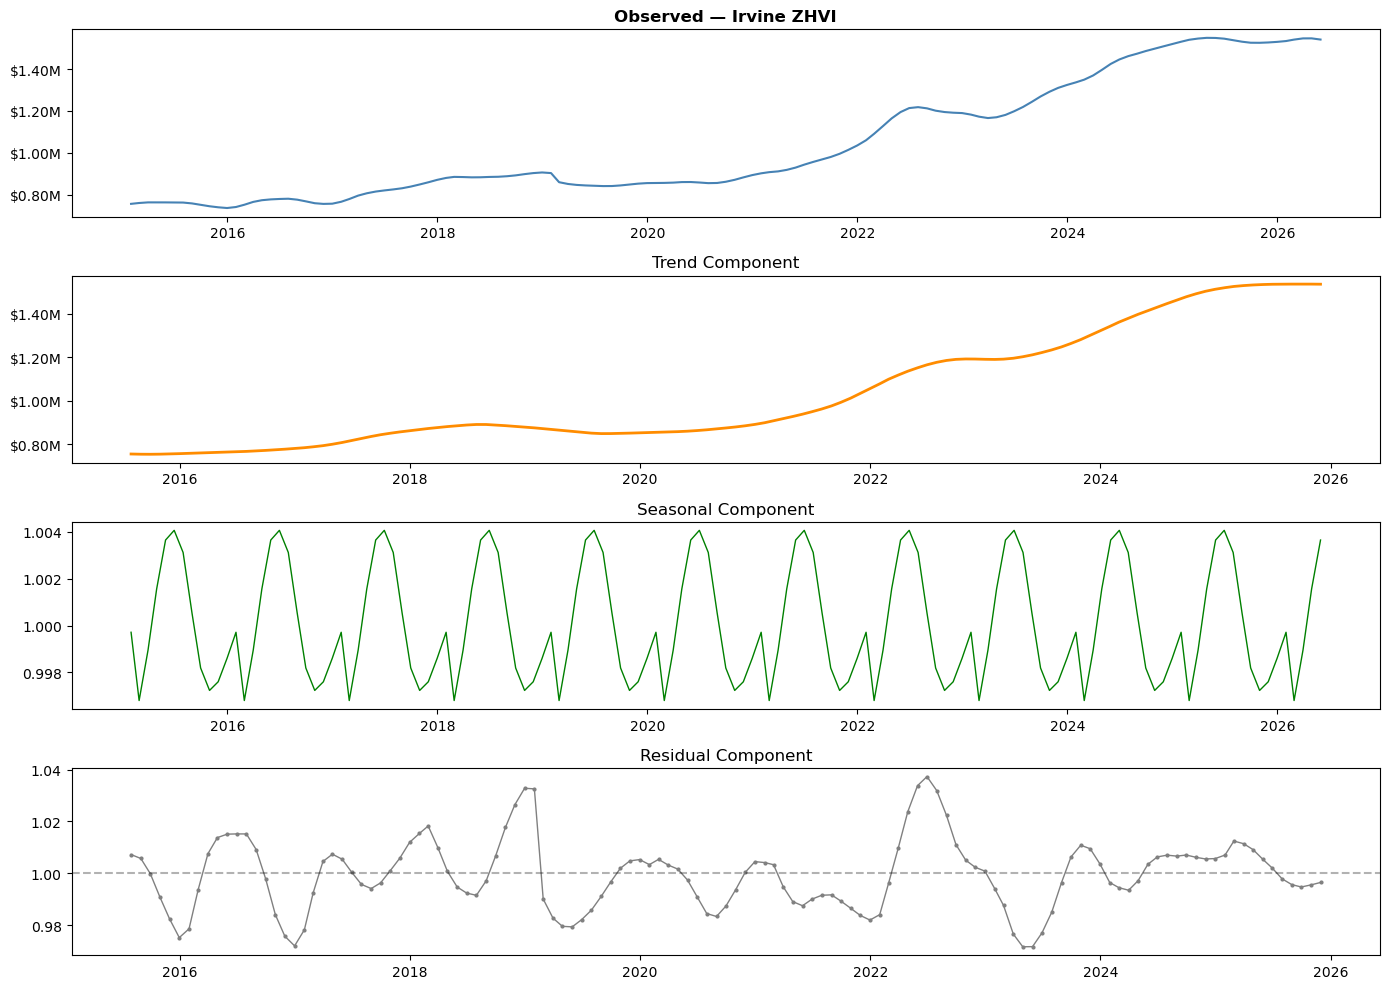

In [5]:
# Decompose the largest city (Irvine, or whichever tops the list) ZHVI into trend + seasonal + residual
primary_city = key_cities[0]
city_series = city_ts[city_ts['City'] == primary_city].copy()
city_series = city_series.set_index('date')['zhvi'].dropna()

decomp = seasonal_decompose(city_series, model='multiplicative', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))

axes[0].plot(city_series, color='steelblue', linewidth=1.5)
axes[0].set_title(f'Observed \u2014 {primary_city} ZHVI', fontweight='bold')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.2f}M'))

axes[1].plot(decomp.trend, color='darkorange', linewidth=2)
axes[1].set_title('Trend Component')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.2f}M'))

axes[2].plot(decomp.seasonal, color='green', linewidth=1)
axes[2].set_title('Seasonal Component')

axes[3].plot(decomp.resid, color='gray', linewidth=1, marker='o', markersize=2)
axes[3].axhline(1.0, color='black', linestyle='--', alpha=0.3)
axes[3].set_title('Residual Component')

plt.tight_layout()
plt.savefig(OUT / 'charts/oc_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. SARIMA forecasting by city

In [6]:
def fit_sarima_forecast(ts: pd.Series, n_forecast: int = 12):
    """
    Fit SARIMA(1,1,1)(1,1,1,12) and return forecast + confidence intervals.
    Using a light model (1,1,1) to avoid overfitting on ~120 months of data.
    """
    ts_clean = ts.dropna()
    if len(ts_clean) < 36:
        return None

    ts_fit = ts_clean[ts_clean.index >= '2018-01-01']

    model = SARIMAX(
        ts_fit,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, 12),
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    result = model.fit(disp=False)

    forecast = result.get_forecast(steps=n_forecast)
    forecast_mean = forecast.predicted_mean
    conf_int = forecast.conf_int(alpha=0.20)  # 80% CI for investment planning

    return {
        'ts_fit': ts_fit,
        'forecast_mean': forecast_mean,
        'conf_int': conf_int,
        'aic': result.aic,
        'result': result,
    }

forecasts = {}
for city in key_cities:
    ts = city_ts[city_ts['City'] == city].set_index('date')['zhvi']
    print(f'Fitting {city}...')
    out = fit_sarima_forecast(ts)
    if out:
        forecasts[city] = out
        latest_val = out['ts_fit'].iloc[-1]
        forecast_12m = out['forecast_mean'].iloc[-1]
        chg = (forecast_12m / latest_val - 1) * 100
        print(f'  AIC: {out["aic"]:.1f} | Forecast 12m: {chg:+.1f}%')
    else:
        print(f'  Insufficient data')

Fitting Irvine...
  AIC: 1510.4 | Forecast 12m: -4.9%
Fitting Anaheim...


  AIC: 1411.9 | Forecast 12m: +4.8%
Fitting Newport Beach...
  AIC: 1642.0 | Forecast 12m: +7.9%
Fitting Santa Ana...


  AIC: 1389.9 | Forecast 12m: +6.8%
Fitting Orange...
  AIC: 1428.4 | Forecast 12m: +0.1%


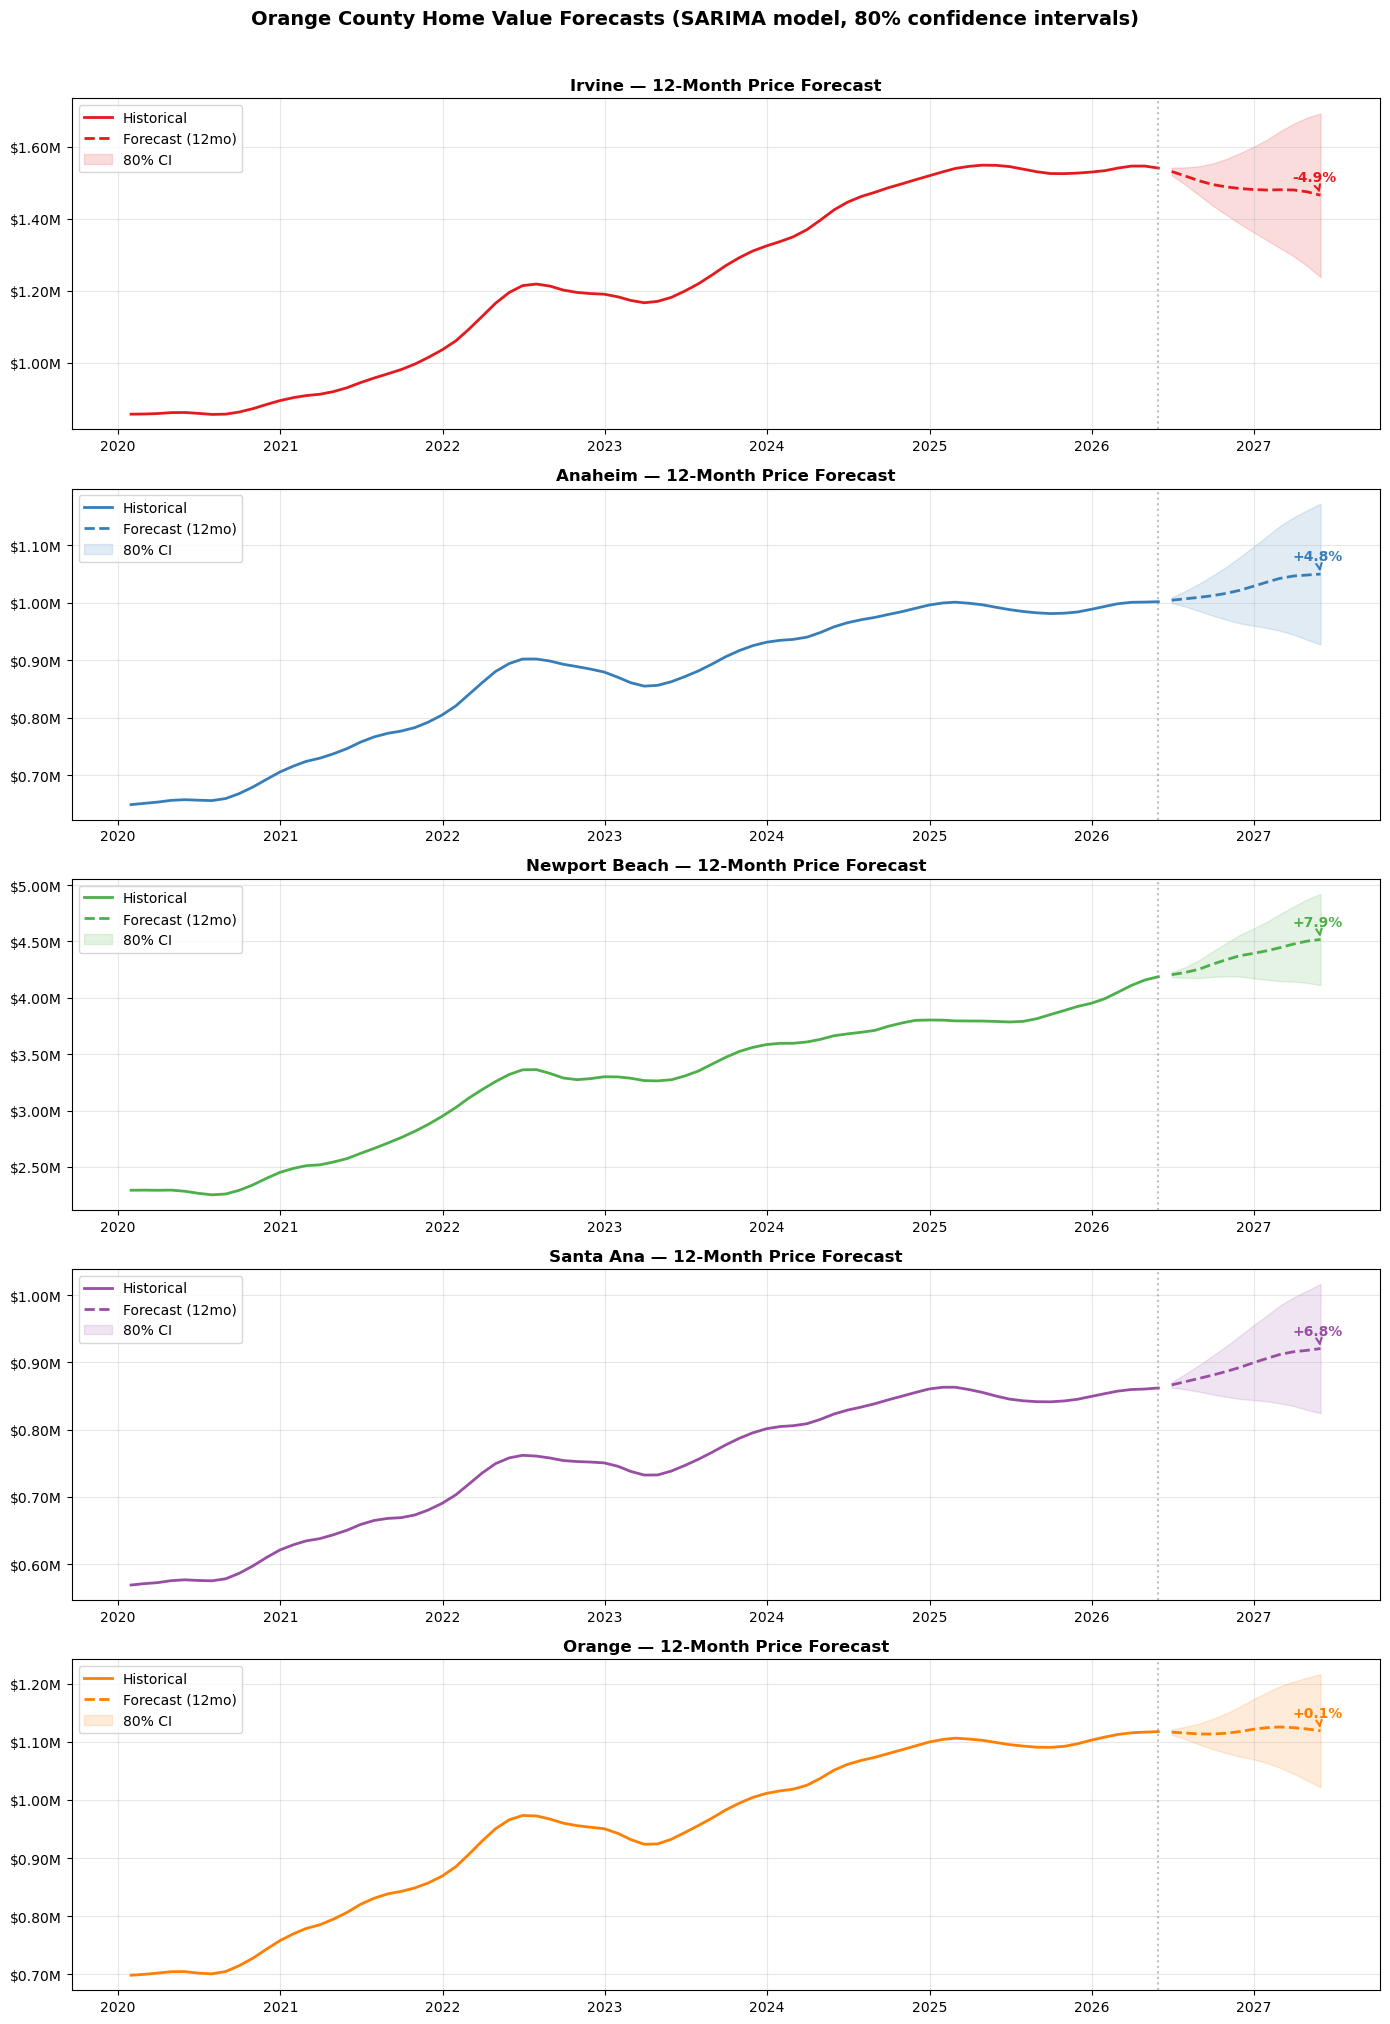

In [7]:
fig, axes = plt.subplots(len(forecasts), 1, figsize=(14, 4 * len(forecasts)))
if len(forecasts) == 1:
    axes = [axes]

colors = ['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00']

for ax, (city, data), color in zip(axes, forecasts.items(), colors):
    ts_plot = data['ts_fit']['2020-01-01':]
    fcast = data['forecast_mean']
    ci = data['conf_int']

    ax.plot(ts_plot.index, ts_plot.values / 1e6, color=color, linewidth=2, label='Historical')
    ax.plot(fcast.index, fcast.values / 1e6, color=color, linewidth=2, linestyle='--', label='Forecast (12mo)')
    ax.fill_between(ci.index, ci.iloc[:, 0] / 1e6, ci.iloc[:, 1] / 1e6, alpha=0.15, color=color, label='80% CI')

    latest = ts_plot.iloc[-1]
    forecast_end = fcast.iloc[-1]
    chg = (forecast_end / latest - 1) * 100
    ax.annotate(
        f'{chg:+.1f}%',
        xy=(fcast.index[-1], forecast_end / 1e6),
        xytext=(-20, 10), textcoords='offset points',
        fontsize=10, fontweight='bold', color=color,
        arrowprops=dict(arrowstyle='->', color=color, lw=1.5)
    )

    ax.axvline(ts_plot.index[-1], color='gray', linestyle=':', alpha=0.5)
    ax.set_title(city + ' \u2014 12-Month Price Forecast', fontweight='bold')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.2f}M'))
    ax.legend(loc='upper left')
    ax.grid(alpha=0.3)

plt.suptitle('Orange County Home Value Forecasts (SARIMA model, 80% confidence intervals)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUT / 'charts/price_forecasts.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Forecast summary table

In [8]:
rows = []
for city, data in forecasts.items():
    ts = data['ts_fit']
    fcast = data['forecast_mean']
    ci = data['conf_int']

    current = ts.iloc[-1]
    f3m = fcast.iloc[2] if len(fcast) > 2 else np.nan
    f6m = fcast.iloc[5] if len(fcast) > 5 else np.nan
    f12m = fcast.iloc[-1]
    ci_low = ci.iloc[-1, 0]
    ci_high = ci.iloc[-1, 1]

    rows.append({
        'City': city,
        'Current Value': f'${current/1e6:.3f}M',
        '3mo Forecast': f'${f3m/1e6:.3f}M' if not np.isnan(f3m) else '-',
        '6mo Forecast': f'${f6m/1e6:.3f}M' if not np.isnan(f6m) else '-',
        '12mo Forecast': f'${f12m/1e6:.3f}M',
        '12mo Chg': f'{(f12m/current - 1)*100:+.1f}%',
        '80% CI (Low)': f'${ci_low/1e6:.3f}M',
        '80% CI (High)': f'${ci_high/1e6:.3f}M',
    })

forecast_table = pd.DataFrame(rows)
forecast_table.to_csv(OUT / 'tables/price_forecasts_12mo.csv', index=False)
print('12-Month Price Forecast Summary')
print('=' * 80)
forecast_table

12-Month Price Forecast Summary


,City,Current Value,3mo Forecast,6mo Forecast,12mo Forecast,12mo Chg,80% CI (Low),80% CI (High)
0,Irvine,$1.541M,$1.505M,$1.484M,$1.465M,-4.9%,$1.238M,$1.693M
1,Anaheim,$1.002M,$1.010M,$1.022M,$1.050M,+4.8%,$0.928M,$1.173M
2,Newport Beach,$4.188M,$4.255M,$4.373M,$4.518M,+7.9%,$4.113M,$4.923M
3,Santa Ana,$0.862M,$0.876M,$0.892M,$0.921M,+6.8%,$0.825M,$1.017M
4,Orange,$1.118M,$1.114M,$1.118M,$1.119M,+0.1%,$1.022M,$1.217M


## 6. Orange County transaction trends (Redfin)

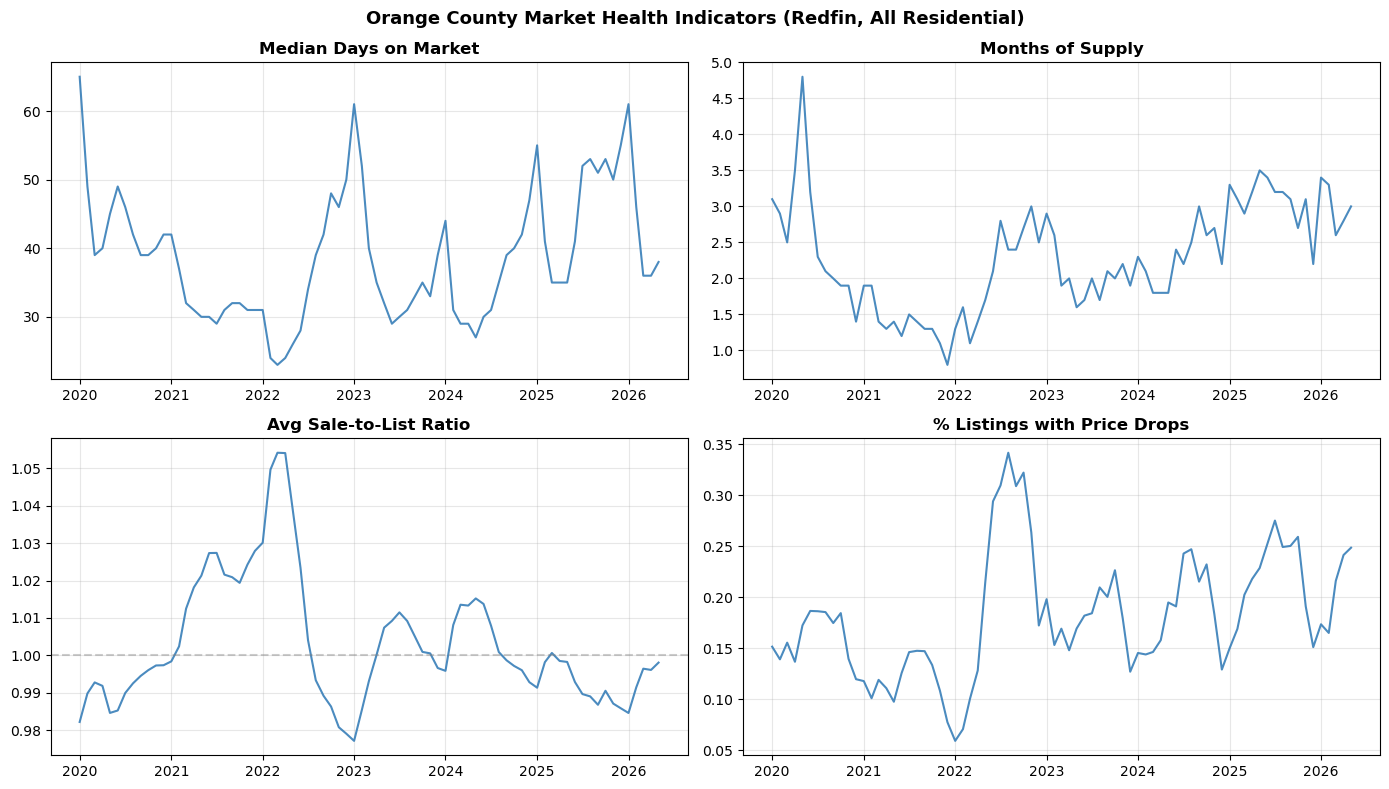

In [9]:
# Supplement ZHVI forecast with Redfin county-level transaction signals
redfin = pd.read_csv(DATA / 'redfin_county_oc.csv')
redfin['PERIOD_BEGIN'] = pd.to_datetime(redfin['PERIOD_BEGIN'])

redfin_recent = redfin[
    (redfin['PROPERTY_TYPE'] == 'All Residential') &
    (redfin['PERIOD_BEGIN'] >= '2020-01-01')
].sort_values('PERIOD_BEGIN')

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

metrics = [
    ('MEDIAN_DOM', 'Median Days on Market', axes[0, 0]),
    ('MONTHS_OF_SUPPLY', 'Months of Supply', axes[0, 1]),
    ('AVG_SALE_TO_LIST', 'Avg Sale-to-List Ratio', axes[1, 0]),
    ('PRICE_DROPS', '% Listings with Price Drops', axes[1, 1]),
]

for col, title, ax in metrics:
    if col not in redfin_recent.columns:
        ax.set_title(f'{title}\n(no data)')
        continue
    ax.plot(redfin_recent['PERIOD_BEGIN'], redfin_recent[col], color='#377eb8', linewidth=1.5, alpha=0.9)
    ax.set_title(title, fontweight='bold')
    ax.grid(alpha=0.3)
    if col == 'AVG_SALE_TO_LIST':
        ax.axhline(1.0, color='gray', linestyle='--', alpha=0.4)

plt.suptitle('Orange County Market Health Indicators (Redfin, All Residential)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT / 'charts/redfin_market_health.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
print('=== PROJECT SUMMARY ===')
print('\nNotebooks completed:')
print('  01_market_selection.ipynb    \u2014 Zip-code ranking by investment attractiveness')
print('  02_distressed_signals.ipynb  \u2014 Seller-motivation signal detection')
print('  03_price_forecasting.ipynb   \u2014 SARIMA 12-month price forecasts by city')
print('\nOutputs generated:')

import os
for root, dirs, files in os.walk('../outputs'):
    for f in files:
        path = os.path.join(root, f)
        size = os.path.getsize(path)
        print(f'  {path} ({size/1024:.0f} KB)')

=== PROJECT SUMMARY ===

Notebooks completed:
  01_market_selection.ipynb    — Zip-code ranking by investment attractiveness
  02_distressed_signals.ipynb  — Seller-motivation signal detection
  03_price_forecasting.ipynb   — SARIMA 12-month price forecasts by city

Outputs generated:
  ../outputs/maps/market_selection_map.html (277 KB)
  ../outputs/tables/market_selection_ranked.csv (20 KB)
  ../outputs/tables/permit_activity_monthly.csv (15 KB)
  ../outputs/tables/distress_scores_ranked.csv (13 KB)
  ../outputs/tables/price_forecasts_12mo.csv (0 KB)
  ../outputs/charts/city_summary.png (188 KB)
  ../outputs/charts/factor_heatmap_top10.png (116 KB)
  ../outputs/charts/opportunity_matrix.png (135 KB)
  ../outputs/charts/permits_over_time.png (178 KB)
  ../outputs/charts/city_price_history.png (138 KB)
  ../outputs/charts/oc_decomposition.png (210 KB)
  ../outputs/charts/price_forecasts.png (356 KB)
  ../outputs/charts/redfin_market_health.png (220 KB)
